In [1]:
import numpy as np
import pandas as pd
from epiweeks import Week
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

In [2]:
def get_data(state): 

    df = pd.read_parquet(f'../load_infodengue_data/data/climate/{state}_climate.parquet')

    df.index = pd.to_datetime(df.index)

    df = df.resample('W-SUN')[['temp_min', 'umid_min']].mean()

    df = df.reset_index()

    df['year'] = df['date'].dt.year

    df['month'] = df['date'].dt.month

    df['SE'] = df.date.apply(
        lambda x: int(f"{Week.fromdate(x).week:02d}")
    )

    return df 

In [3]:
state = 'PR'

df = pd.read_parquet(f'../load_infodengue_data/data/climate/{state}_climate.parquet')

df.index = pd.to_datetime(df.index)

df = df.resample('W-SUN')[['temp_min', 'umid_min']].mean()

df = df.reset_index()

df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['SE'] = df.date.apply(
    lambda x: int(f"{Week.fromdate(x).week:02d}")
)

df.head()

,date,temp_min,umid_min,year,month,SE
0,2000-01-02,19.865418,68.326506,2000,1,1
1,2000-01-09,19.562408,59.264601,2000,1,2
2,2000-01-16,21.409222,62.683035,2000,1,3
3,2000-01-23,21.379136,54.556920,2000,1,4
4,2000-01-30,19.741260,48.517762,2000,1,5


In [4]:
el_nino_2_sem = [2014, 2015, 2018, 2023]

In [5]:
def make_plot(df, ax, color= 'tab:red', column = 'temp_min'):
    
    for y in df.year.unique(): 

        df_ = df.loc[(df.year == y) & (df.month >= 7) & (df.SE <=53) & (df.SE > 20)]

        if y in el_nino_2_sem: 
            ax.plot(df_.SE, df_[column].values, color = color, zorder=5 )

        else: 
            ax.plot(df_.SE, df_[column].values, color = 'lightgray' )

    ax.plot(df_.SE, df_.temp_min, color = color, zorder=0, label = 'El Niño')
    ax.plot(df_.SE, df_.temp_min, color = 'lightgray', zorder=0, label = 'Outros anos')

    ax.legend()

    ax.grid()


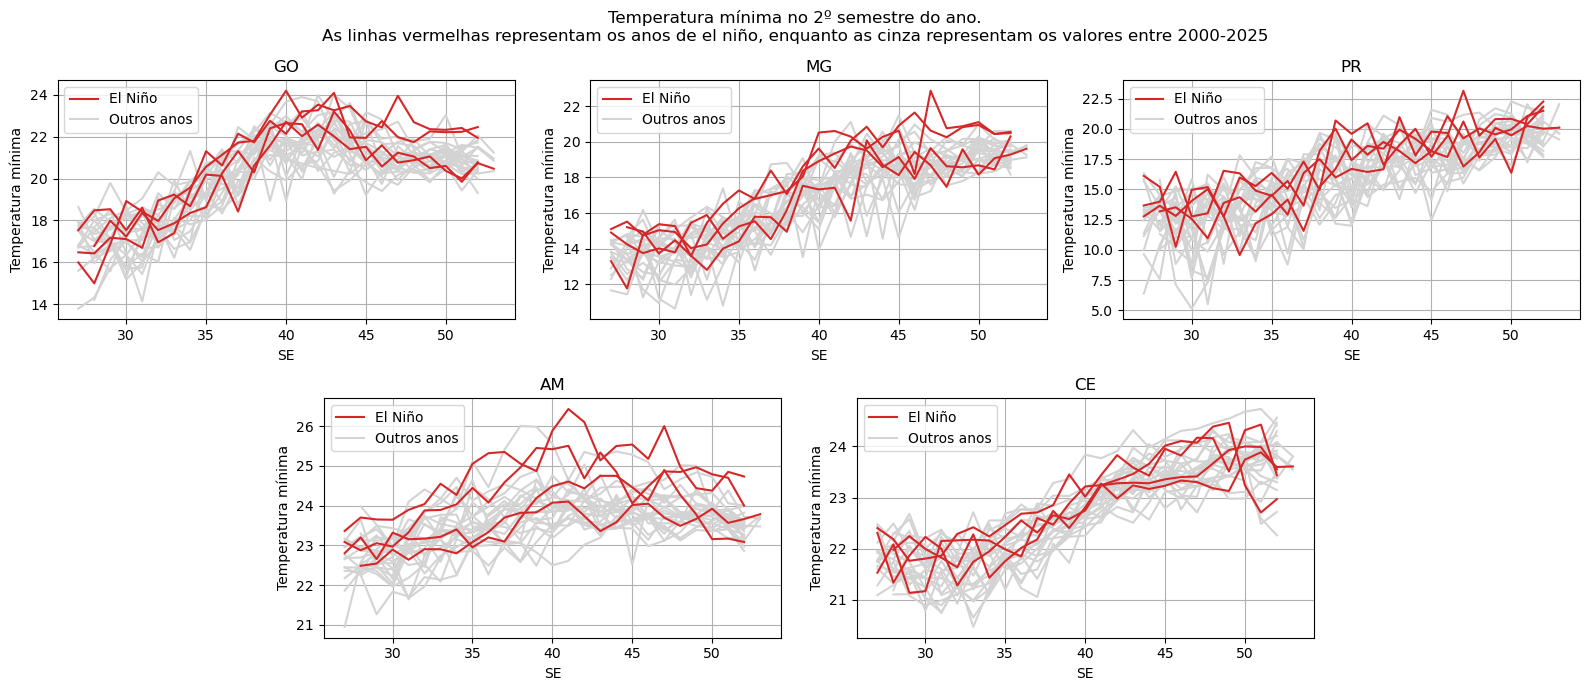

In [6]:
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 6, figure=fig)

# First row with three boxplots
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])

# Second row with two boxplots
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])

for r, ax in zip(['GO', 'MG', 'PR', 'AM', 'CE'], [ax1,ax2,ax3,ax4,ax5]):

    df = get_data(r)

    make_plot(df, ax, color= 'tab:red', column = 'temp_min')

    ax.set_title(r)
    ax.set_xlabel('SE')
    ax.set_ylabel('Temperatura mínima')

plt.suptitle('Temperatura mínima no 2º semestre do ano.\nAs linhas vermelhas representam os anos de el niño, enquanto as cinza representam os valores entre 2000-2025')
# Adjust layout
plt.tight_layout()
plt.savefig('temp_min_uf.png', dpi = 200, bbox_inches = 'tight')
plt.show()

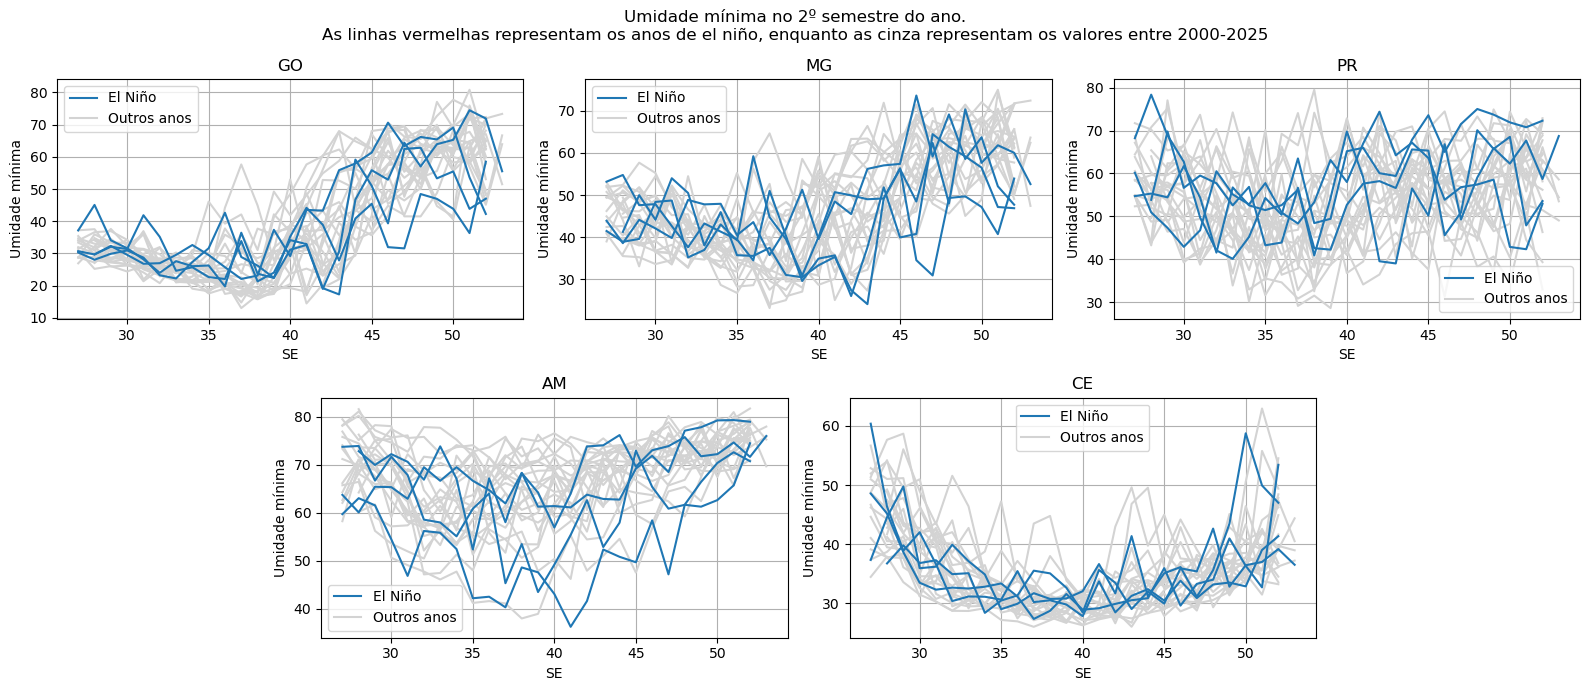

In [7]:
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 6, figure=fig)

# First row with three boxplots
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])

# Second row with two boxplots
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])

for r, ax in zip(['GO', 'MG', 'PR', 'AM', 'CE'], [ax1,ax2,ax3,ax4,ax5]):

    df = get_data(r)

    make_plot(df, ax, color= 'tab:blue', column = 'umid_min')

    ax.set_title(r)
    ax.set_xlabel('SE')
    ax.set_ylabel('Umidade mínima')

plt.suptitle('Umidade mínima no 2º semestre do ano.\nAs linhas vermelhas representam os anos de el niño, enquanto as cinza representam os valores entre 2000-2025')
# Adjust layout
plt.tight_layout()
plt.savefig('umid_min_uf.png', dpi = 200, bbox_inches = 'tight')
plt.show()

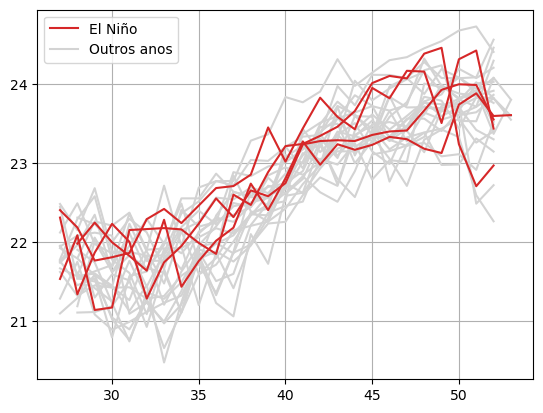

In [8]:
_, ax = plt.subplots()

for y in df.year.unique(): 

    df_ = df.loc[(df.year == y) & (df.month >= 7) & (df.SE <=53) & (df.SE > 20)]

    if y in el_nino_2_sem: 
        ax.plot(df_.SE, df_.temp_min, color = 'tab:red', zorder=5 )

    else: 
        ax.plot(df_.SE, df_.temp_min, color = 'lightgray' )

ax.plot(df_.SE, df_.temp_min, color = 'tab:red', zorder=0, label = 'El Niño')
ax.plot(df_.SE, df_.temp_min, color = 'lightgray', zorder=0, label = 'Outros anos')

ax.legend()

ax.grid()
plt.show()

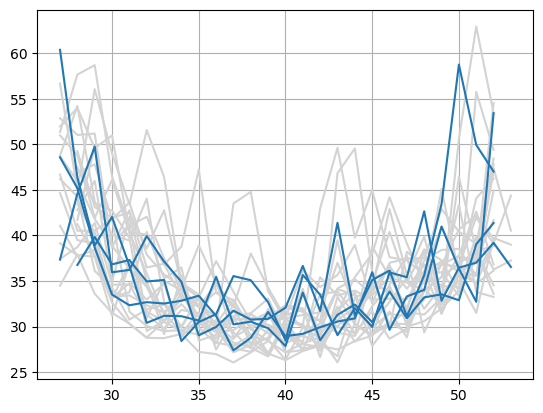

In [9]:
_, ax = plt.subplots()

for y in df.year.unique(): 

    df_ = df.loc[(df.year == y) & (df.month >= 7) & (df.SE <=53) & (df.SE > 20)]

    if y in el_nino_2_sem: 
        ax.plot(df_.SE, df_.umid_min, color = 'tab:blue', zorder=5 )

    else: 
        ax.plot(df_.SE, df_.umid_min, color = 'lightgray' )

ax.grid()
plt.show()